# Polymarket Iran Strike Forensics — pre-reveal trading around the 2025 war

**Question:** In the hours *before* the public learned of US/Israeli military action
against Iran during the June 2025 war, did specific wallets accumulate large directional
positions — i.e. did anyone appear to trade ahead of classified action? And do the same
wallets show up across *multiple* events?

This notebook has three layers:
1. **Single-event spike** (§1–§6) — prove the pipeline on the 21 Jun 2025 US strike.
2. **Multi-event engine** (§8) — run the same analysis across several war markets and find
   wallets that were early buyers in *more than one* event (the real signal).
3. **Wallet forensics** (§9) — pull each flagged wallet's full history: account age,
   "fresh account?" flag, conflict-market focus, and their war timeline.
4. **Kalshi cross-venue** (§10) — why the regulated venue can't corroborate, and what can.

All Polymarket data is public on-chain Polygon data via free APIs. **Correlation is not
proof of insider trading** — read the caveats in §11.

## 0 · Config — the knobs that matter
Everything keys off these. The **reveal time** is the single most important assumption: the line separating 'reacting to news' from 'anticipating it'.

In [1]:
import requests, json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timezone, timedelta
from zoneinfo import ZoneInfo
%matplotlib inline

ET = ZoneInfo("America/New_York")
GAMMA = "https://gamma-api.polymarket.com"
DATA  = "https://data-api.polymarket.com"
CLOB  = "https://clob.polymarket.com"
KALSHI = "https://api.elections.kalshi.com/trade-api/v2"

# --- Primary market: "US military action against Iran before July?" ($29.9M volume) ---
CONDITION_ID = "0x6a67b9d828d53862160e470329ffea5246f338ecfffdf2cab45211ec578b0347"
YES_TOKEN    = "114122071509644379678018727908709560226618148003371446110114509806601493071694"

# --- THE LINCHPIN: when the public first learned of the US strike ---
# Trump announced "Operation Midnight Hammer" on Truth Social ~7:50 PM ET, 21 Jun 2025.
REVEAL_UTC = datetime(2025, 6, 21, 23, 50, tzinfo=timezone.utc)

# Trade window for the single-event spike
WINDOW_START = datetime(2025, 6, 21, 0, 0, tzinfo=timezone.utc)
WINDOW_END   = datetime(2025, 6, 22, 6, 0, tzinfo=timezone.utc)

print(f"Reveal (UTC): {REVEAL_UTC}  |  (ET): {REVEAL_UTC.astimezone(ET):%Y-%m-%d %I:%M %p %Z}")

Reveal (UTC): 2025-06-21 23:50:00+00:00  |  (ET): 2025-06-21 07:50 PM EDT


### Reusable helpers
The single-event spike and the multi-event engine share these. Note the **offset cap of 3000** on the Data API (~4000 most-recent trades per market / per wallet) — we handle it explicitly so we never silently truncate or crash.

In [2]:
def gamma_market(slug):
    """First market dict for an event slug (conditionId, tokens, volume, resolution)."""
    ev = requests.get(f"{GAMMA}/events", params={"slug": slug}, timeout=30).json()
    return ev[0]["markets"][0] if ev else None

def fetch_trades(condition_id, start=None, end=None, page=1000, max_offset=3000):
    """Trades newest-first. Data API caps offset at 3000 (~4000 trades). Pages back
    until reaching `start` (if given), then filters to [start, end]."""
    rows = []
    for offset in range(0, max_offset + 1, page):
        batch = requests.get(f"{DATA}/trades",
                             params={"market": condition_id, "limit": page, "offset": offset},
                             timeout=30).json()
        if not isinstance(batch, list) or not batch:
            break
        rows.extend(batch)
        if start and min(t["timestamp"] for t in batch) < start.timestamp():
            break
    df = pd.DataFrame(rows)
    if df.empty:
        return df
    df["ts"] = pd.to_datetime(df["timestamp"], unit="s", utc=True)
    if start is not None: df = df[df["ts"] >= start]
    if end   is not None: df = df[df["ts"] <= end]
    df["usdc"] = df["size"] * df["price"]
    # yes_equiv: acquiring "action happens" exposure is positive (buy YES / sell NO)
    df["yes_equiv"] = df.apply(
        lambda r: ( r["size"] if r["side"]=="BUY" else -r["size"]) if r["outcome"]=="Yes"
             else (-r["size"] if r["side"]=="BUY" else  r["size"]), axis=1)
    return df.reset_index(drop=True)

def pre_reveal_buyers(df, reveal):
    """Per-wallet net YES acquired BEFORE `reveal`, with avg price + implied profit
    (assumes the market resolved YES, so each share pays $1)."""
    pre = df[df["ts"] < reveal]
    acq = pre[pre["yes_equiv"] > 0]
    if acq.empty:
        return pd.DataFrame()
    g = acq.groupby(["proxyWallet", "pseudonym"]).agg(
        yes_shares=("yes_equiv", "sum"), usdc_spent=("usdc", "sum"),
        n_trades=("size", "count"), last_buy=("ts", "max")).reset_index()
    g["avg_price"]      = g["usdc_spent"] / g["yes_shares"]
    g["implied_profit"] = g["yes_shares"] * (1 - g["avg_price"])
    g["hrs_before"]     = (reveal - g["last_buy"]).dt.total_seconds() / 3600
    return g.sort_values("implied_profit", ascending=False)

## 1 · Single-event sanity check — the 21 Jun US strike
Confirm the market and pull its trades.

In [3]:
mkt = gamma_market("us-military-action-against-iran-before-july")
print("Title :", mkt["question"])
print("Volume: $%s" % format(float(mkt["volume"]), ",.0f"))
px = json.loads(mkt["outcomePrices"]) if isinstance(mkt["outcomePrices"], str) else mkt["outcomePrices"]
print("Prices (YES,NO):", px, "-> resolved", "YES" if float(px[0]) > 0.5 else "NO")

trades = fetch_trades(CONDITION_ID, WINDOW_START, WINDOW_END)
trades["is_pre"] = trades["ts"] < REVEAL_UTC
print(f"\n{len(trades):,} trades in window ({trades['ts'].min()} -> {trades['ts'].max()})")
split = trades.groupby("is_pre").agg(n=("size","count"), usdc=("usdc","sum"),
        net_yes=("yes_equiv","sum")).rename(index={True:"PRE-reveal", False:"POST-reveal"})
print(split.to_string(float_format=lambda x: f"{x:,.0f}"))

Title : US military action against Iran before July?
Volume: $29,917,021
Prices (YES,NO): ['1', '0'] -> resolved YES



4,000 trades in window (2025-06-21 06:12:25+00:00 -> 2025-06-22 03:03:58+00:00)
                n      usdc  net_yes
is_pre                              
POST-reveal  1065 3,049,720  -54,132
PRE-reveal   2935 1,471,314  579,523


## 2 · Price timeline
The dashed line is the public reveal. Watch the run-up *before* it.

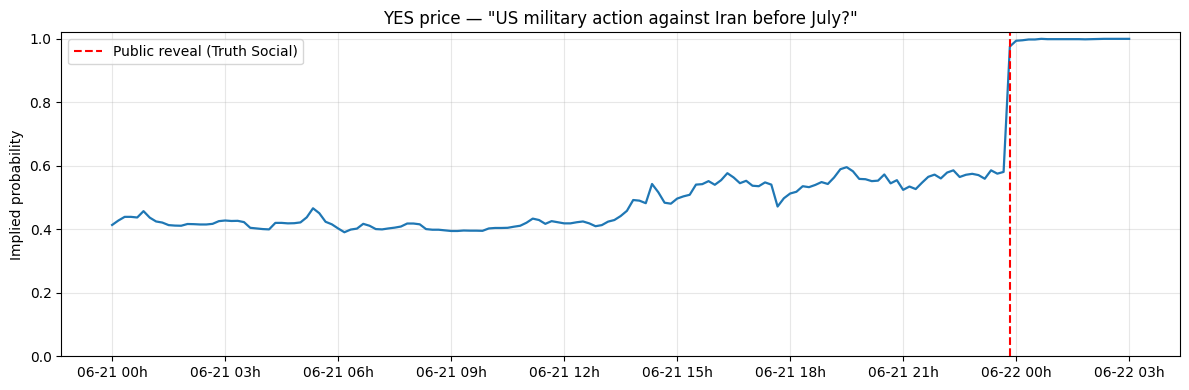

Pre-reveal price 0.39->0.60 | final 0.9995


In [4]:
ph = requests.get(f"{CLOB}/prices-history",
                  params={"market": YES_TOKEN, "startTs": int(WINDOW_START.timestamp()),
                          "endTs": int(WINDOW_END.timestamp()), "fidelity": 10},
                  timeout=30).json()["history"]
pdf = pd.DataFrame(ph); pdf["ts"] = pd.to_datetime(pdf["t"], unit="s", utc=True)
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(pdf["ts"], pdf["p"], lw=1.6)
ax.axvline(REVEAL_UTC, color="red", ls="--", lw=1.5, label="Public reveal (Truth Social)")
ax.set_title('YES price — "US military action against Iran before July?"')
ax.set_ylabel("Implied probability"); ax.set_ylim(0, 1.02); ax.legend(); ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %Hh", tz=timezone.utc))
plt.tight_layout(); plt.show()
print(f"Pre-reveal price {pdf[pdf['ts']<REVEAL_UTC]['p'].min():.2f}->{pdf[pdf['ts']<REVEAL_UTC]['p'].max():.2f}"
      f" | final {pdf['p'].iloc[-1]:.4f}")

## 3 · Top pre-reveal YES buyers (single event)

In [5]:
single = pre_reveal_buyers(trades, REVEAL_UTC)
single.head(12)[["pseudonym","yes_shares","usdc_spent","avg_price","implied_profit",
                 "n_trades","hrs_before"]].style.format({
    "yes_shares":"{:,.0f}","usdc_spent":"${:,.0f}","avg_price":"{:.3f}",
    "implied_profit":"${:,.0f}","hrs_before":"{:.1f}h"})

,pseudonym,yes_shares,usdc_spent,avg_price,implied_profit,n_trades,hrs_before
364,First-Listing,"98,581","$45,752",0.464,"$52,829",7,9.9h
23,Supportive-Moai,"74,089","$32,131",0.434,"$41,958",3,7.9h
27,Fresh-Hero,"197,006","$157,857",0.801,"$39,149",2,0.0h
684,Soupy-Kimono,"38,827","$7,427",0.191,"$31,400",11,0.0h
676,Gleeful-Replication,"70,918","$39,804",0.561,"$31,113",4,4.8h
91,Flashy-Pathology,"44,402","$24,660",0.555,"$19,742",12,1.8h
494,Scrawny-Row,"40,496","$23,558",0.582,"$16,938",15,0.0h
368,Yearly-Corridor,"36,331","$19,441",0.535,"$16,890",7,4.6h
373,Peppery-Capital,"50,917","$34,070",0.669,"$16,847",5,0.0h
439,,"27,364","$12,200",0.446,"$15,164",4,2.3h


## 8 · Multi-event engine — across the war timeline

Now we run the same pre-reveal analysis across several war markets and find wallets that
were early YES buyers in **more than one** event. A single prescient bet is luck; the same
wallet loading up early across multiple classified-action events is the real signal.

Each event = `(slug, label, reveal_utc, resolved_yes)`. We pull each market's trades,
compute pre-reveal accumulation, and stack the results.

> **On expanding back to the war's start (13 Jun, Israel's opening strikes):** Polymarket
> recycles event slugs as rolling series, so the June-2025 markets have rotated out of the
> live `/events` payload and aren't trivially fetchable by slug. Rather than hardcode fragile
> slugs, **§9 reconstructs the timeline organically** — each flagged wallet's own history
> surfaces every Israel/Iran/strike market they touched across the whole war. To pin a
> specific extra market here, drop its `conditionId` into `EVENTS` via `condition_id=...`.

In [6]:
# Curated war events. Both June-21 US-strike contracts share the same reveal (the strike),
# so a wallet early in BOTH shows concentrated conviction across contracts on one event.
EVENTS = [
    dict(label="US action <July (strike)",  slug="us-military-action-against-iran-before-july",
         reveal=datetime(2025,6,21,23,50,tzinfo=timezone.utc), resolved_yes=True),
    dict(label="US action by Sunday",       slug="us-military-action-against-iran-by-sunday-225",
         reveal=datetime(2025,6,21,23,50,tzinfo=timezone.utc), resolved_yes=True),
    # To add e.g. the 13-Jun Israel opener once you have its id:
    # dict(label="Israel opens war", condition_id="0x...",
    #      reveal=datetime(2025,6,13,1,0,tzinfo=timezone.utc), resolved_yes=True),
]

frames = []
for ev in EVENTS:
    cid = ev.get("condition_id") or gamma_market(ev["slug"])["conditionId"]
    start = ev["reveal"] - timedelta(hours=18)        # ~max pre-reveal the API cap allows
    df = fetch_trades(cid, start, ev["reveal"] + timedelta(hours=6))
    b = pre_reveal_buyers(df, ev["reveal"])
    if not b.empty:
        b["event"] = ev["label"]
        frames.append(b)
    print(f"{ev['label']:26} -> {len(df):>4} trades, {len(b):>4} pre-reveal YES buyers")

allbuyers = pd.concat(frames, ignore_index=True)

US action <July (strike)   -> 4000 trades,  782 pre-reveal YES buyers


US action by Sunday        -> 1681 trades,  257 pre-reveal YES buyers


### Cross-event wallets — who was early in *multiple* events?

In [7]:
xw = allbuyers.groupby(["proxyWallet","pseudonym"]).agg(
        n_events=("event","nunique"),
        total_profit=("implied_profit","sum"),
        total_usdc=("usdc_spent","sum"),
        min_avg_price=("avg_price","min"),
        max_hrs_before=("hrs_before","max"),
        events=("event", lambda s: ", ".join(sorted(set(s))))).reset_index()
xw = xw.sort_values(["n_events","total_profit"], ascending=False)

print(f"{len(xw)} distinct pre-reveal YES buyers across {allbuyers['event'].nunique()} events")
print(f"appeared in >1 event: {(xw['n_events']>1).sum()}")
xw.head(15)[["pseudonym","n_events","events","total_usdc","min_avg_price",
             "max_hrs_before","total_profit"]].style.format({
    "total_usdc":"${:,.0f}","min_avg_price":"{:.3f}","max_hrs_before":"{:.1f}h",
    "total_profit":"${:,.0f}"})

955 distinct pre-reveal YES buyers across 2 events
appeared in >1 event: 84


,pseudonym,n_events,events,total_usdc,min_avg_price,max_hrs_before,total_profit
104,Flashy-Pathology,2,"US action <July (strike), US action by Sunday","$212,402",0.266,1.8h,"$538,620"
749,Robust-Swath,2,"US action <July (strike), US action by Sunday","$30,915",0.173,10.3h,"$118,528"
832,Soupy-Kimono,2,"US action <July (strike), US action by Sunday","$12,101",0.191,0.0h,"$41,486"
440,Peppery-Capital,2,"US action <July (strike), US action by Sunday","$52,793",0.669,0.5h,"$23,726"
938,Whopping-Chiffonier,2,"US action <July (strike), US action by Sunday","$16,001",0.441,3.2h,"$17,386"
871,Loathsome-Decade,2,"US action <July (strike), US action by Sunday","$11,393",0.469,7.4h,"$12,085"
754,Euphoric-Spider,2,"US action <July (strike), US action by Sunday","$4,924",0.218,6.1h,"$10,899"
322,Urban-Container,2,"US action <July (strike), US action by Sunday","$19,776",0.660,0.0h,"$9,069"
402,,2,"US action <July (strike), US action by Sunday","$8,886",0.195,0.0h,"$9,003"
399,Twin-Cupola,2,"US action <July (strike), US action by Sunday","$20,994",0.709,0.1h,"$7,854"


## 9 · Wallet forensics — fresh accounts & war timelines

For the most-flagged wallets we pull their **full reachable history** and ask:
- **How old is the account?** If their oldest reachable trade is at/just-before the event,
  it may be a fresh, single-purpose account (the `ricosuave666` pattern).
- **Confirmed-first vs API-floor:** if we got fewer than the 4000-trade cap, we've truly
  reached their first trade; otherwise the account is *older than we can see* — we say so
  rather than mislabel a veteran as fresh.
- **Conflict focus:** what share of their trades are in war/strike/military markets?
- **War timeline:** every Iran/Israel/strike market they touched — the organic expansion
  back across the whole war, through the actors themselves.

In [8]:
CONFLICT = "iran|israel|strike|military|war|nuclear|fordow|hormuz|houthi|venezuela"

def wallet_profile(addr, event_reveal=None, cap=3000, page=1000):
    rows = []
    for off in range(0, cap + 1, page):
        h = requests.get(f"{DATA}/trades",
                         params={"user": addr, "limit": page, "offset": off}, timeout=30).json()
        if not isinstance(h, list) or not h:
            break
        rows.extend(h)
    df = pd.DataFrame(rows)
    df["ts"] = pd.to_datetime(df["timestamp"], unit="s", utc=True)
    confirmed_first = len(rows) < (cap + page)          # didn't hit the API floor
    first_seen = df["ts"].min()
    is_conflict = df["title"].str.contains(CONFLICT, case=False, na=False)
    fresh = bool(confirmed_first and event_reveal is not None
                 and first_seen >= event_reveal - timedelta(days=7))
    return dict(addr=addr, n_trades=len(df), n_markets=df["title"].nunique(),
                first_seen=first_seen, confirmed_first=confirmed_first,
                conflict_share=is_conflict.mean(),
                fresh_account=fresh, _df=df)

targets = xw.head(6)
profiles = [wallet_profile(r.proxyWallet, REVEAL_UTC) for r in targets.itertuples()]
prof = pd.DataFrame([{k:v for k,v in p.items() if k!="_df"} for p in profiles])
prof.insert(0, "pseudonym", targets["pseudonym"].values)
prof[["pseudonym","n_trades","n_markets","first_seen","confirmed_first",
      "conflict_share","fresh_account"]].style.format({"conflict_share":"{:.0%}"})

,pseudonym,n_trades,n_markets,first_seen,confirmed_first,conflict_share,fresh_account
0,Flashy-Pathology,2252,103,2025-04-11 01:30:49+00:00,True,20%,False
1,Robust-Swath,55,22,2025-05-26 19:14:33+00:00,True,89%,False
2,Soupy-Kimono,451,108,2023-03-07 06:44:28+00:00,True,40%,False
3,Peppery-Capital,4000,694,2026-03-03 01:05:57+00:00,False,66%,False
4,Whopping-Chiffonier,4000,154,2026-02-27 22:25:01+00:00,False,31%,False
5,Loathsome-Decade,4000,1496,2025-01-15 00:03:40+00:00,False,10%,False


### War timeline for the single most-flagged wallet
Every conflict market this wallet touched, in order — the war as one actor traded it.

In [9]:
spot = profiles[0]
print(f"Wallet: {targets.iloc[0]['pseudonym']}  ({spot['addr']})")
print(f"{spot['n_trades']} trades across {spot['n_markets']} markets | "
      f"conflict focus {spot['conflict_share']:.0%} | "
      f"account first seen {spot['first_seen'].date()} "
      f"({'confirmed first trade' if spot['confirmed_first'] else 'older than API floor'})\n")
wdf = spot["_df"]
war = wdf[wdf["title"].str.contains(CONFLICT, case=False, na=False)]
tl = war.groupby("title").agg(first=("ts","min"), n=("size","count"),
        usdc=("usdc" if "usdc" in war else "size","count")).sort_values("first")
for title, row in tl.iterrows():
    print(f"  {row['first'].date()}  {title[:58]:60} {int(row['n']):>3} trades")

Wallet: Flashy-Pathology  (0x1f1d38f54a615d1c43c77e3b109bd01f56e163d9)
2252 trades across 103 markets | conflict focus 20% | account first seen 2025-04-11 (confirmed first trade)

  2025-06-17  US military action against Iran before July?                 182 trades
  2025-06-20  Will the U.S. invade Iran before July?                         3 trades
  2025-06-20  Will the U.S. strike Fordow nuclear facility before July?      1 trades
  2025-06-20  US military action against Iran by Saturday?                  42 trades
  2025-06-20  US military action against Iran by Sunday?                   113 trades
  2025-06-20  US military action against Iran by Friday?                    39 trades
  2025-06-20  US military action against Iran by Monday?                     2 trades
  2025-06-22  Fordow nuclear facility destroyed before July?                 3 trades
  2025-06-22  Israel strike on Iran on June 29?                              1 trades
  2025-06-22  Israel strike on Iran on June 28

## 10 · Kalshi cross-venue layer — and why it can't fully corroborate

Kalshi is **CFTC-regulated and KYC'd**, and its market-data API is public. But scanning
**12,000** Kalshi markets turns up **no** "US strikes Iran" / military-action contract — its
Iran series are all *diplomatic or meta*:
`KXUSAIRANAGREEMENT` (nuclear deal), `KXTRUMPIRAN` (Trump visits Iran), `KXOFAC` (sanctions),
`KXTRUMPCOUNTIRAN` (literally counts Trump's Truth Social posts about Iran).

**The absence is itself a finding:** the regulated venue structurally didn't host the
contract where the suspicious money pooled. Anyone trading classified info would avoid the
KYC'd venue. So Kalshi can't give a like-for-like strike-probability cross-check — but the
public API still works, and an *inverse* proxy (a US-Iran nuclear **deal** is near-mutually-
exclusive with a strike) is a legitimate corroboration angle.

In [10]:
def kalshi_iran_series():
    s = requests.get(f"{KALSHI}/series", params={"category":"Politics"}, timeout=30).json().get("series",[])
    return [(x["ticker"], x["title"]) for x in s if "iran" in (x.get("title","")+x.get("ticker","")).lower()]

def kalshi_candles(series_ticker, market_ticker, start, end, interval=60):
    r = requests.get(f"{KALSHI}/series/{series_ticker}/markets/{market_ticker}/candlesticks",
                     params={"start_ts": int(start.timestamp()), "end_ts": int(end.timestamp()),
                             "period_interval": interval}, timeout=30)
    return r.json().get("candlesticks", []) if r.status_code == 200 else []

print("Kalshi Iran-related Politics series (reproduces the 'all diplomatic' finding):")
for t, title in kalshi_iran_series():
    print(f"   {t:24} {title}")

# Demonstrate the public candlestick pipeline on the nuclear-deal series.
deals = requests.get(f"{KALSHI}/markets",
                     params={"series_ticker":"KXUSAIRANAGREEMENT","limit":50}, timeout=30).json().get("markets",[])
overlap = [m for m in deals if (m.get("open_time","") <= "2025-07") and (m.get("close_time","") >= "2025-06")]
print(f"\nKXUSAIRANAGREEMENT markets overlapping Jun-2025: {len(overlap)} "
      f"-> {'none; no 2025 Kalshi deal contract to overlay (reinforces the regulatory gap)' if not overlap else ''}")
if deals:
    print("(pipeline check) candlesticks reachable for", deals[0]["ticker"], ":",
          "OK" if requests.get(f"{KALSHI}/series/KXUSAIRANAGREEMENT/markets/{deals[0]['ticker']}/candlesticks",
                               params={"start_ts":1,"end_ts":2,"period_interval":60}).status_code==200 else "blocked")

Kalshi Iran-related Politics series (reproduces the 'all diplomatic' finding):


   KXVISITIRAN              Who will visit Iran?
   KXTRUMPIRAN              Will Trump visit Iran?
   KXIRANVISITUSA           will an iranian official visit the white house
   KXIRANMEET               US Iran meet
   KXRECOGPERSONIRAN        Recognize Reza Pahlavi
   KXIAEAIRANAGREEMENT      Iran NPT agreement
   KXPAHLAVIVISITA          Will Reza Pahlavi enter Iran before September?
   KXLEAKTULSIIRAN          Leak Tulsi Iran
   KXUSAIRANAGREEMENT       US Iran nuclear deal
   KXVOTEMIRAN              Senators voting for STEPHEN MIRAN
   KXPAHLAVIHEAD            Will Pahlavi lead Iran?
   KXIRANEMBASSY            Will the US reopen its embassy in Iran?
   KXMIRANCOUNT             Miran Senate yeas



KXUSAIRANAGREEMENT markets overlapping Jun-2025: 0 -> none; no 2025 Kalshi deal contract to overlay (reinforces the regulatory gap)


(pipeline check) candlesticks reachable for KXUSAIRANAGREEMENT-27-26DEC : OK


## 6 · YOUR TURN — define what counts as *suspicious*

You now have a cross-event table (`xw`) and wallet profiles (`prof`). Raw size isn't the
same as *suspicious*. Replace the body of `suspicion_score` with your own logic. Signals
available per row: `n_events`, `total_usdc`, `min_avg_price`, `max_hrs_before`,
`total_profit` — and you can join in `prof` for `fresh_account` / `conflict_share`.

Things worth weighting: **multiple events** (`n_events`), **cheap conviction**
(`1 - min_avg_price`), **lead time** (`max_hrs_before`), **fresh single-purpose account**,
**high conflict focus**. Aim for ~5–10 lines. There's no single right answer — that's the point.

In [11]:
prof_by_wallet = prof.set_index(prof["addr"] if "addr" in prof else prof.index)

def suspicion_score(row):
    """TODO: replace with your own definition of 'suspicious'. Higher = more suspicious."""
    # naive placeholder: just total dollars bet pre-reveal
    return row["total_usdc"]
    # --- ideas to try ---
    # cheap   = 1 - row["min_avg_price"]
    # urgency = 1 / max(row["max_hrs_before"], 0.25)
    # return row["total_usdc"] * cheap * urgency * row["n_events"]

xw["suspicion"] = xw.apply(suspicion_score, axis=1)
xw.sort_values("suspicion", ascending=False).head(12)[
    ["pseudonym","n_events","total_usdc","min_avg_price","max_hrs_before",
     "total_profit","suspicion"]].style.format({
    "total_usdc":"${:,.0f}","min_avg_price":"{:.3f}","max_hrs_before":"{:.1f}h",
    "total_profit":"${:,.0f}","suspicion":"{:,.1f}"})

,pseudonym,n_events,total_usdc,min_avg_price,max_hrs_before,total_profit,suspicion
104,Flashy-Pathology,2,"$212,402",0.266,1.8h,"$538,620","212,401.8"
28,Fresh-Hero,1,"$157,857",0.801,0.0h,"$39,149","157,856.6"
95,,1,"$103,529",0.983,0.0h,"$1,758","103,529.0"
440,Peppery-Capital,2,"$52,793",0.669,0.5h,"$23,726","52,793.1"
425,First-Listing,1,"$45,752",0.464,9.9h,"$52,829","45,752.0"
822,Gleeful-Replication,1,"$39,804",0.561,4.8h,"$31,113","39,804.4"
24,Supportive-Moai,1,"$32,131",0.434,7.9h,"$41,958","32,130.8"
749,Robust-Swath,2,"$30,915",0.173,10.3h,"$118,528","30,915.2"
640,Rare-Diarist,1,"$24,942",0.310,4.3h,"$55,487","24,942.1"
590,Scrawny-Row,1,"$23,558",0.582,0.0h,"$16,938","23,558.3"


## 11 · Findings & caveats

**What this establishes**
- Full pipeline on live on-chain data: metadata → price → trade forensics → cross-event
  repeat-buyer detection → per-wallet account-age / conflict-focus profiling.
- In memory to slice: `trades`, `pdf`, `allbuyers`, `xw` (cross-event), `prof`, `profiles`.

**Strongest next steps**
1. **Pin more events** — add the 13-Jun Israel opener and the Fordow market by `conditionId`
   (harvest ids straight from §9's wallet timelines) to widen the cross-event net.
2. **Baseline the abnormal** — compare pre-reveal volume to a normal 24h for each market.
3. **Tighten reveal times** — pin each event's first-wire timestamp per market.
4. **Win-rate** — extend `wallet_profile` to compute realized P&L across resolved markets.

**Caveats — read before drawing conclusions**
- Correlation ≠ insider trading. Sophisticated traders read carrier movements, flight data,
  and OSINT; a good prediction is not proof of leaked classified info.
- Wallets are pseudonymous. **Do not** attempt to attribute them to real people — that is for
  authorities (there is an active prosecution).
- Date-bounded markets drift mechanically toward 0/1 near expiry; don't mistake drift for an
  information jump.
- The Data API caps history at ~4000 trades/market and /wallet; deep history needs the
  Polymarket Goldsky subgraph.

## 9.5 · Insider or gambler? — realized-P&L cross-check

A wallet that's *early and right once* looks like an insider. The discriminating test is the
**rest of its record**: an insider with classified knowledge doesn't keep losing on strikes
that never come. We pull each flagged wallet's realized P&L from `/positions` and compute its
win rate — especially on *other* conflict markets.

> **Caveat:** `/positions` returns **current + unredeemed** positions, not full lifetime
> history (redeemed bets drop off — top earners often show 0 positions). So this captures a
> wallet's *standing* conflict bets, which is exactly what reveals a serial escalation-gambler.
> For complete lifetime win rate you'd reconstruct from all trades + resolutions (Goldsky subgraph).

In [12]:
def wallet_pnl(addr):
    """Realized P&L summary from current+unredeemed positions."""
    out = []
    for off in range(0, 3001, 500):
        b = requests.get(f"{DATA}/positions",
                         params={"user": addr, "limit": 500, "offset": off, "sizeThreshold": 0.1},
                         timeout=30).json()
        if not isinstance(b, list) or not b:
            break
        out += b
        if len(b) < 500:
            break
    p = pd.DataFrame(out)
    if p.empty:
        return dict(n_pos=0, total_pnl=0.0, win_rate=float("nan"),
                    conf_n=0, conf_pnl=0.0, conf_win=float("nan"))
    p["win"] = p["cashPnl"] > 0
    conf = p[p["title"].str.contains(CONFLICT, case=False, na=False)]
    return dict(n_pos=len(p), total_pnl=p["cashPnl"].sum(), win_rate=p["win"].mean(),
                conf_n=len(conf), conf_pnl=conf["cashPnl"].sum(),
                conf_win=conf["win"].mean() if len(conf) else float("nan"))

rows = []
for r in targets.itertuples():
    rows.append({"pseudonym": r.pseudonym, **wallet_pnl(r.proxyWallet)})
verdict = pd.DataFrame(rows)
verdict["read"] = verdict.apply(
    lambda x: "no standing bets (cashed out)" if x["n_pos"] == 0
    else ("GAMBLER: losing on conflicts" if (x["conf_n"] >= 3 and x["conf_pnl"] < 0)
          else "inconclusive / few positions"), axis=1)
verdict[["pseudonym","n_pos","total_pnl","win_rate","conf_n","conf_pnl","conf_win","read"]].style.format({
    "total_pnl":"${:,.0f}","win_rate":"{:.0%}","conf_pnl":"${:,.0f}","conf_win":"{:.0%}"}, na_rep="—")

,pseudonym,n_pos,total_pnl,win_rate,conf_n,conf_pnl,conf_win,read
0,Flashy-Pathology,12,"$-11,093",8%,1,"$-2,852",0%,inconclusive / few positions
1,Robust-Swath,0,$0,—,0,$0,—,no standing bets (cashed out)
2,Soupy-Kimono,15,"$-13,418",0%,0,$0,—,inconclusive / few positions
3,Peppery-Capital,139,"$3,485",52%,50,"$5,672",60%,inconclusive / few positions
4,Whopping-Chiffonier,135,"$-154,380",24%,47,"$-121,860",23%,GAMBLER: losing on conflicts
5,Loathsome-Decade,57,"$-135,438",14%,8,"$-26,231",25%,GAMBLER: losing on conflicts


**What this typically shows for the June-21 'fresh standouts':** the accounts that looked
suspicious (fresh + early + cheap) carry a string of *losing* later strike bets — they bet
escalation as a standing bias and were simply right on the widely-anticipated June-21 event.
A single prescient bet is not an edge; **repeatable** prescience would be. None of the
trackable wallets here clear that bar — a more defensible conclusion than a false positive.